# Telecom X — Análisis de evasión (Churn)

Este notebook importa los datos desde el JSON de Telecom X, los transforma a un DataFrame, limpia inconsistencias, crea la variable `Cuentas_Diarias`, estandariza nombres y desarrolla un análisis descriptivo y exploratorio sobre churn.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (9, 5)
RAW_URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

Matplotlib is building the font cache; this may take a moment.


## 1. Extracción

In [2]:
try:
    response = requests.get(RAW_URL, timeout=30)
    response.raise_for_status()
    data_json = response.json()
    fuente = "remota (GitHub raw)"
except Exception:
    import json
    local_path = "TelecomX_Data.json"
    with open(local_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    fuente = f"local ({local_path})"

print(f"Fuente utilizada: {fuente}")
print(f"Registros descargados: {len(data_json):,}")
df_raw = pd.json_normalize(data_json, sep="_")
print(f"Dimensiones iniciales: {df_raw.shape}")

df_raw.head()

Fuente utilizada: local (TelecomX_Data.json)
Registros descargados: 7,267
Dimensiones iniciales: (7267, 21)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 2. Exploración de columnas y tipos de datos

In [3]:
display(pd.DataFrame({'columna': df_raw.columns, 'dtype': df_raw.dtypes.astype(str)}))
df_raw.info()

,columna,dtype
customerID,customerID,object
Churn,Churn,object
customer_gender,customer_gender,object
customer_SeniorCitizen,customer_SeniorCitizen,int64
customer_Partner,customer_Partner,object
customer_Dependents,customer_Dependents,object
customer_tenure,customer_tenure,int64
phone_PhoneService,phone_PhoneService,object
phone_MultipleLines,phone_MultipleLines,object
internet_InternetService,internet_InternetService,object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

## 3. Diccionario de trabajo

- `customerID`: identificador del cliente  
- `Churn`: variable objetivo  
- `customer_*`: datos demográficos y antigüedad  
- `phone_*`: variables del servicio telefónico  
- `internet_*`: variables de internet y servicios asociados  
- `account_*`: contrato, método de pago y cobros

In [4]:
diccionario_trabajo = pd.DataFrame({
    'columna': df_raw.columns,
    'descripcion': [
        'ID único del cliente',
        'Indica evasión del cliente',
        'Género',
        'Adulto mayor (0/1)',
        'Tiene pareja',
        'Tiene dependientes',
        'Antigüedad en meses',
        'Tiene servicio telefónico',
        'Tiene múltiples líneas',
        'Tipo de internet',
        'Seguridad online',
        'Respaldo online',
        'Protección de dispositivo',
        'Soporte técnico',
        'Streaming TV',
        'Streaming películas',
        'Tipo de contrato',
        'Facturación sin papel',
        'Método de pago',
        'Cargo mensual',
        'Cargo total acumulado'
    ]
})
display(diccionario_trabajo)

,columna,descripcion
0,customerID,ID único del cliente
1,Churn,Indica evasión del cliente
2,customer_gender,Género
3,customer_SeniorCitizen,Adulto mayor (0/1)
4,customer_Partner,Tiene pareja
5,customer_Dependents,Tiene dependientes
6,customer_tenure,Antigüedad en meses
7,phone_PhoneService,Tiene servicio telefónico
8,phone_MultipleLines,Tiene múltiples líneas
9,internet_InternetService,Tipo de internet


## 4. Calidad de datos

In [5]:
nulos = df_raw.isna().sum().sort_values(ascending=False)
vacios_texto = {
    col: df_raw[col].astype(str).str.strip().eq('').sum()
    for col in df_raw.select_dtypes(include='object').columns
}
display(nulos.to_frame('nulos'))
display(pd.Series(vacios_texto, name='vacios_texto').sort_values(ascending=False).to_frame())

print('Duplicados de filas completas:', df_raw.duplicated().sum())
print('Duplicados por customerID:', df_raw['customerID'].duplicated().sum())

,nulos
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


,vacios_texto
Churn,224
account_Charges_Total,11
customerID,0
customer_gender,0
customer_Dependents,0
customer_Partner,0
phone_MultipleLines,0
internet_InternetService,0
internet_OnlineSecurity,0
phone_PhoneService,0


Duplicados de filas completas: 0
Duplicados por customerID: 0


In [6]:
for col in df_raw.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df_raw[col].astype(str).str.strip().value_counts(dropna=False).head(10))


--- customerID ---
customerID
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
0013-EXCHZ    1
0013-MHZWF    1
0013-SMEOE    1
0014-BMAQU    1
0015-UOCOJ    1
0016-QLJIS    1
Name: count, dtype: int64

--- Churn ---
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

--- customer_gender ---
customer_gender
Male      3675
Female    3592
Name: count, dtype: int64

--- customer_Partner ---
customer_Partner
No     3749
Yes    3518
Name: count, dtype: int64

--- customer_Dependents ---
customer_Dependents
No     5086
Yes    2181
Name: count, dtype: int64

--- phone_PhoneService ---
phone_PhoneService
Yes    6560
No      707
Name: count, dtype: int64

--- phone_MultipleLines ---
phone_MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

--- internet_InternetService ---
internet_InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

--- internet_Onlin

## 5. Limpieza y tratamiento

Decisiones:
- limpiar espacios en texto,
- convertir `account_Charges_Total` a numérico,
- imputar `Cargo_Total = 0` cuando el valor esté vacío y `tenure = 0`,
- eliminar registros con `Churn` faltante del dataset analítico.

In [7]:
df = df_raw.copy()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

df['Churn'] = df['Churn'].replace({'': np.nan})
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

mask_total_na = df['account_Charges_Total'].isna()
df.loc[mask_total_na & (df['customer_tenure'] == 0), 'account_Charges_Total'] = 0

df_clean = df.dropna(subset=['Churn']).copy()

print('Shape original:', df_raw.shape)
print('Shape limpio:', df_clean.shape)
print('Registros excluidos por churn faltante:', df_raw.shape[0] - df_clean.shape[0])

df_clean.head()

Shape original: (7267, 21)
Shape limpio: (7043, 21)
Registros excluidos por churn faltante: 224


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## 6. Crear `Cuentas_Diarias`

In [8]:
df_clean['Cuentas_Diarias'] = df_clean['account_Charges_Monthly'] / 30
df_clean[['account_Charges_Monthly', 'Cuentas_Diarias']].head()

,account_Charges_Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


## 7. Estandarización

In [9]:
df_std = df_clean.copy()

bin_map = {'Yes': 1, 'No': 0}
for col in ['customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'account_PaperlessBilling']:
    df_std[col + '_bin'] = df_std[col].map(bin_map)

df_std['Churn_bin'] = df_std['Churn'].map(bin_map)
df_std['customer_SeniorCitizen_bin'] = df_std['customer_SeniorCitizen'].astype(int)

rename_map = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer_gender': 'Genero',
    'customer_SeniorCitizen': 'Adulto_Mayor',
    'customer_Partner': 'Tiene_Pareja',
    'customer_Dependents': 'Tiene_Dependientes',
    'customer_tenure': 'Meses_Cliente',
    'phone_PhoneService': 'Servicio_Telefono',
    'phone_MultipleLines': 'Multiples_Lineas',
    'internet_InternetService': 'Servicio_Internet',
    'internet_OnlineSecurity': 'Seguridad_Online',
    'internet_OnlineBackup': 'Respaldo_Online',
    'internet_DeviceProtection': 'Proteccion_Dispositivo',
    'internet_TechSupport': 'Soporte_Tecnico',
    'internet_StreamingTV': 'Streaming_TV',
    'internet_StreamingMovies': 'Streaming_Peliculas',
    'account_Contract': 'Tipo_Contrato',
    'account_PaperlessBilling': 'Facturacion_Sin_Papel',
    'account_PaymentMethod': 'Metodo_Pago',
    'account_Charges_Monthly': 'Cargo_Mensual',
    'account_Charges_Total': 'Cargo_Total'
}

df_es = df_std.rename(columns=rename_map)
print(df_es.shape)
df_es.head()

(7043, 28)


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Cliente,Servicio_Telefono,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Sin_Papel,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,customer_Partner_bin,customer_Dependents_bin,phone_PhoneService_bin,account_PaperlessBilling_bin,Churn_bin,customer_SeniorCitizen_bin
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,1,1,1,1,0,0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0,0,1,0,0,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,0,0,1,1,1,0
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1,0,1,1,1,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1,0,1,1,1,1


## 8. Análisis descriptivo

In [10]:
cols_num = ['Meses_Cliente', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']
display(df_es[cols_num].describe().T)

,count,mean,std,min,25%,50%,75%,max
Meses_Cliente,7043.0,32.371149,24.559481,0.000000,9.000000,29.000,55.000,72.000000
Cargo_Mensual,7043.0,64.761692,30.090047,18.250000,35.500000,70.350,89.850,118.750000
Cargo_Total,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550,3786.600,8684.800000
Cuentas_Diarias,7043.0,2.158723,1.003002,0.608333,1.183333,2.345,2.995,3.958333


## 9. Distribución de evasión

,conteo,porcentaje
Evasion,,
No,5174,73.46
Yes,1869,26.54


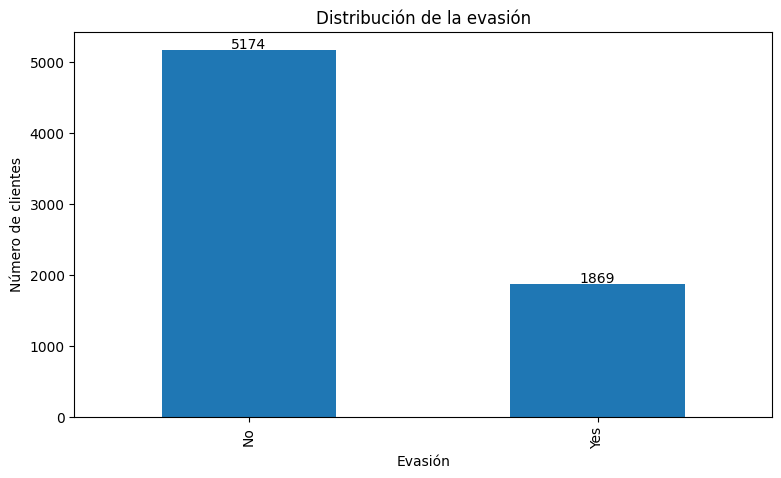

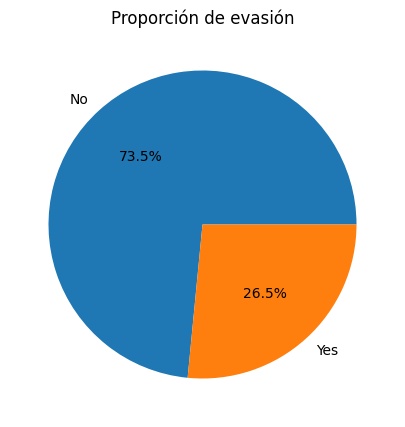

In [11]:
conteo_churn = df_es['Evasion'].value_counts()
prop_churn = df_es['Evasion'].value_counts(normalize=True).mul(100).round(2)

display(pd.DataFrame({'conteo': conteo_churn, 'porcentaje': prop_churn}))

ax = conteo_churn.plot(kind='bar')
ax.set_title('Distribución de la evasión')
ax.set_xlabel('Evasión')
ax.set_ylabel('Número de clientes')
for i, v in enumerate(conteo_churn.values):
    ax.text(i, v + 20, str(v), ha='center')
plt.show()

prop_churn.plot(kind='pie', autopct='%1.1f%%', ylabel='', title='Proporción de evasión')
plt.show()

## 10. Evasión por variables categóricas


### Genero


Evasion,No,Yes,Total
Genero,,,
Female,73.08,26.92,3488
Male,73.84,26.16,3555


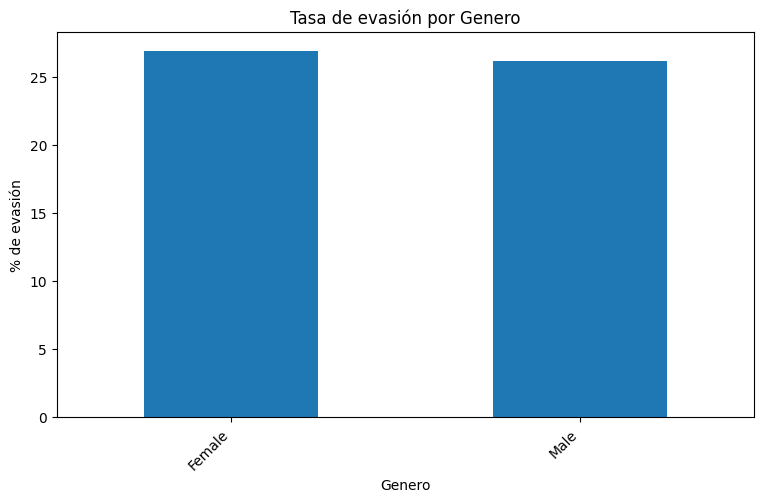


### Adulto_Mayor


Evasion,No,Yes,Total
Adulto_Mayor,,,
1,58.32,41.68,1142
0,76.39,23.61,5901


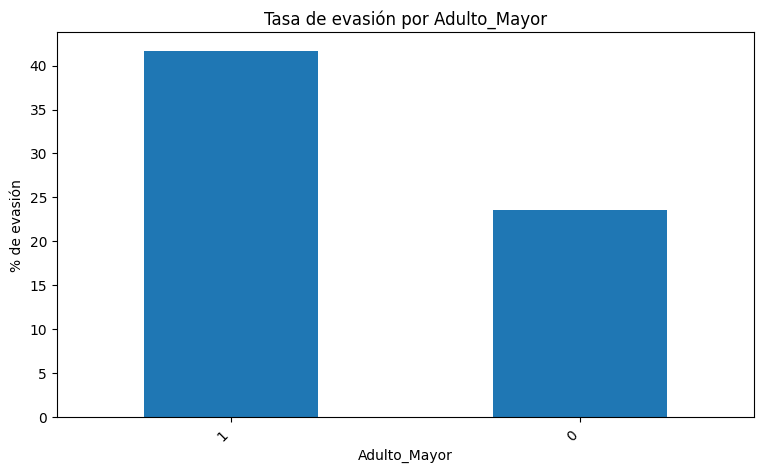


### Tipo_Contrato


Evasion,No,Yes,Total
Tipo_Contrato,,,
Month-to-month,57.29,42.71,3875
One year,88.73,11.27,1473
Two year,97.17,2.83,1695


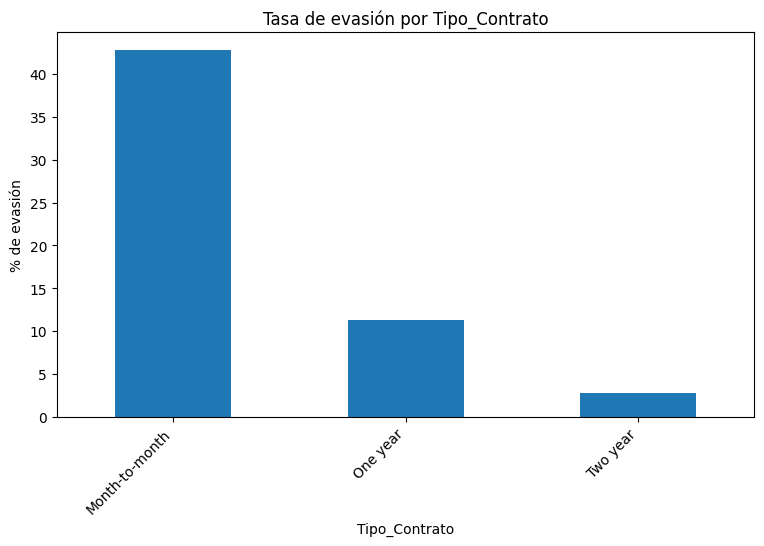


### Metodo_Pago


Evasion,No,Yes,Total
Metodo_Pago,,,
Electronic check,54.71,45.29,2365
Mailed check,80.89,19.11,1612
Bank transfer (automatic),83.29,16.71,1544
Credit card (automatic),84.76,15.24,1522


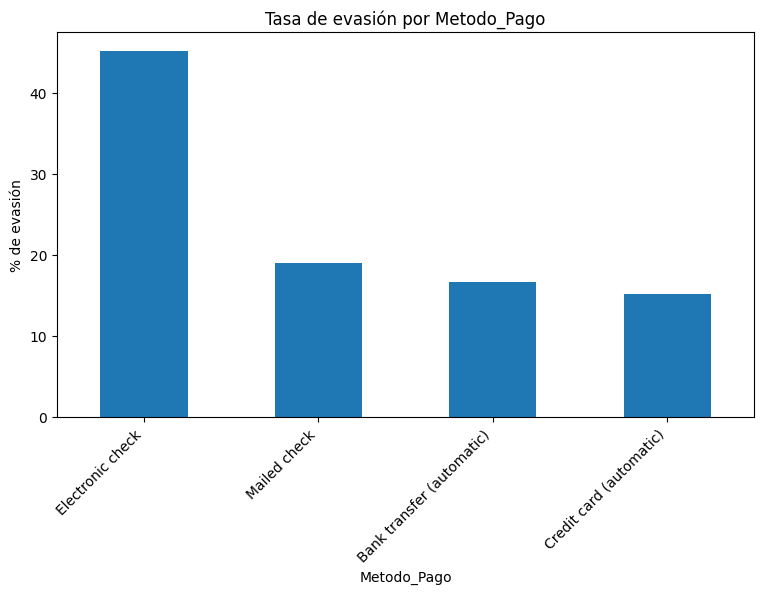


### Servicio_Internet


Evasion,No,Yes,Total
Servicio_Internet,,,
Fiber optic,58.11,41.89,3096
DSL,81.04,18.96,2421
No,92.60,7.40,1526


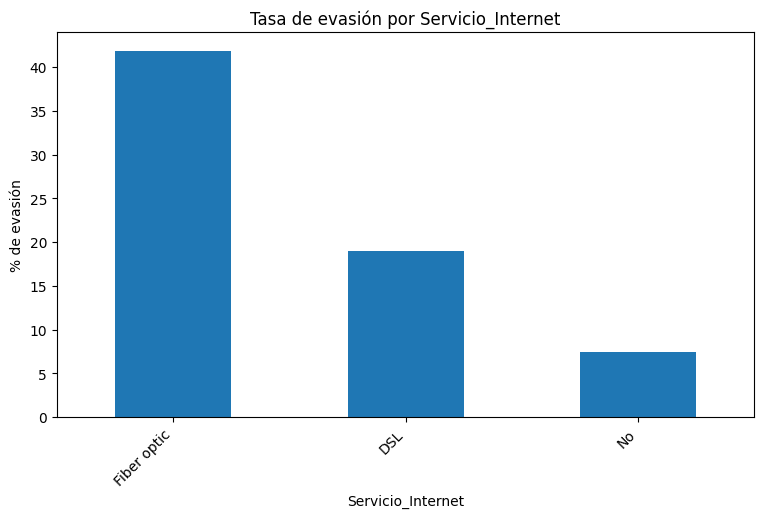


### Facturacion_Sin_Papel


Evasion,No,Yes,Total
Facturacion_Sin_Papel,,,
Yes,66.43,33.57,4171
No,83.67,16.33,2872


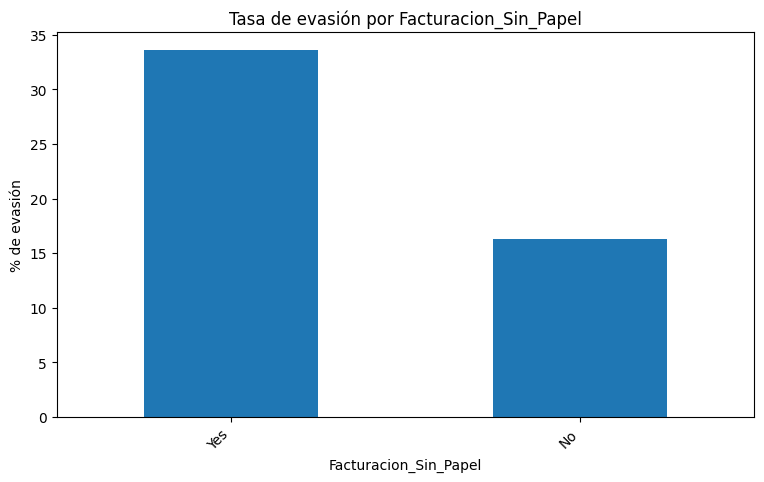


### Seguridad_Online


Evasion,No,Yes,Total
Seguridad_Online,,,
No,58.23,41.77,3498
Yes,85.39,14.61,2019
No internet service,92.60,7.40,1526


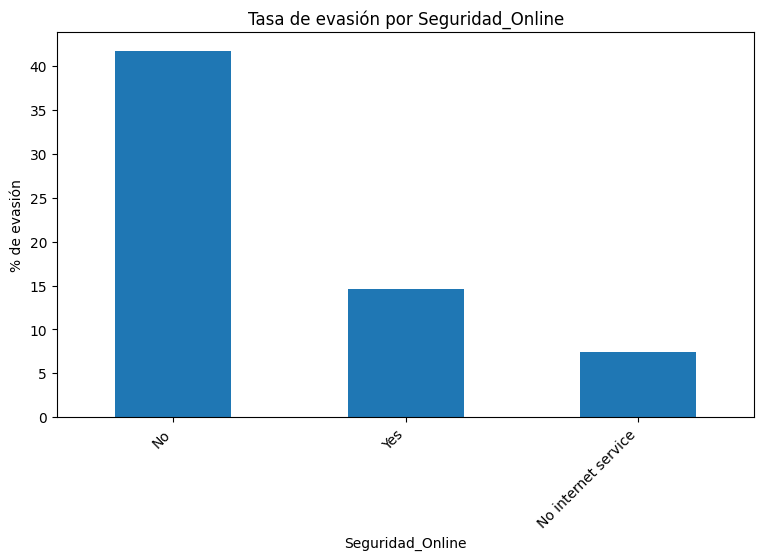


### Soporte_Tecnico


Evasion,No,Yes,Total
Soporte_Tecnico,,,
No,58.36,41.64,3473
Yes,84.83,15.17,2044
No internet service,92.60,7.40,1526


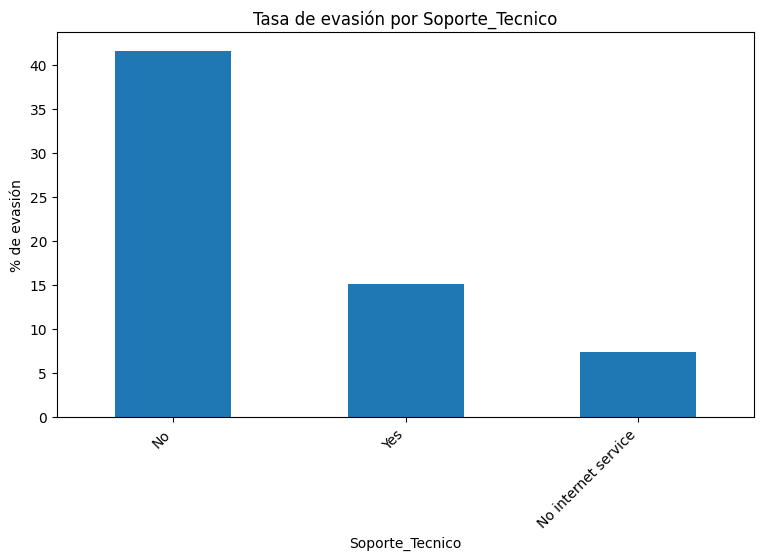

In [12]:
def churn_por_categoria(df, col):
    tabla = pd.crosstab(df[col], df['Evasion'], normalize='index').mul(100).round(2)
    tabla['Total'] = df[col].value_counts()
    tabla = tabla.sort_values('Yes', ascending=False)
    display(tabla)
    ax = tabla['Yes'].plot(kind='bar')
    ax.set_title(f'Tasa de evasión por {col}')
    ax.set_ylabel('% de evasión')
    plt.xticks(rotation=45, ha='right')
    plt.show()

for col in ['Genero', 'Adulto_Mayor', 'Tipo_Contrato', 'Metodo_Pago', 'Servicio_Internet',
            'Facturacion_Sin_Papel', 'Seguridad_Online', 'Soporte_Tecnico']:
    print(f"\n### {col}")
    churn_por_categoria(df_es, col)

## 11. Evasión y variables numéricas

In [13]:
resumen_num = df_es.groupby('Evasion')[['Meses_Cliente', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']].agg(['mean', 'median', 'std']).round(2)
display(resumen_num)

Meses_Cliente                ... Cuentas_Diarias             
                 mean median    std  ...            mean median   std
Evasion                              ...                             
No              37.57   38.0  24.11  ...            2.04   2.15  1.04
Yes             17.98   10.0  19.53  ...            2.48   2.66  0.82

[2 rows x 12 columns]

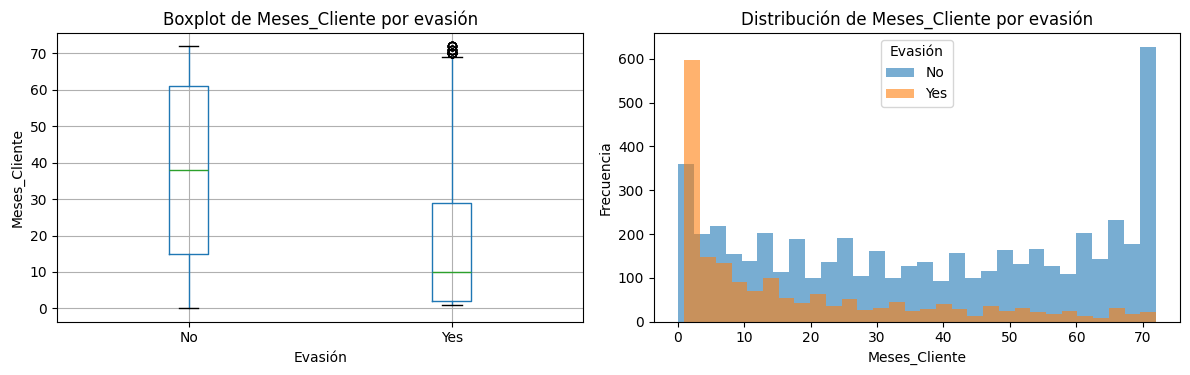

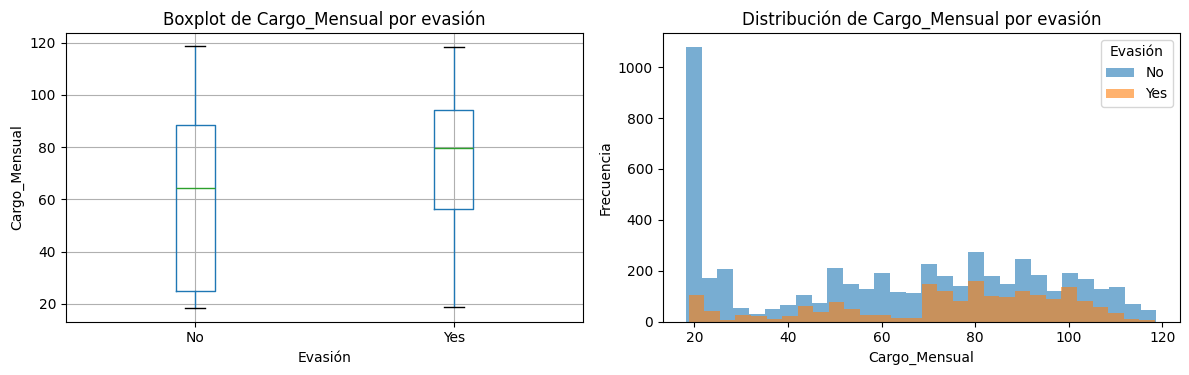

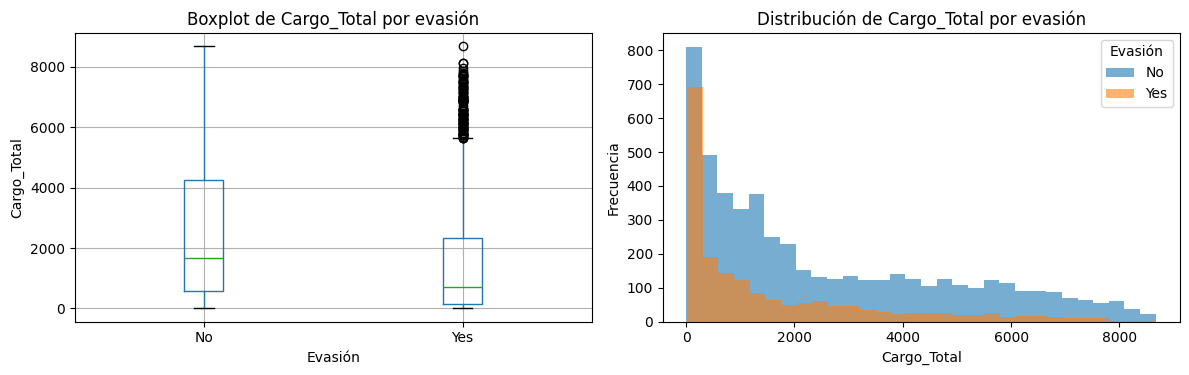

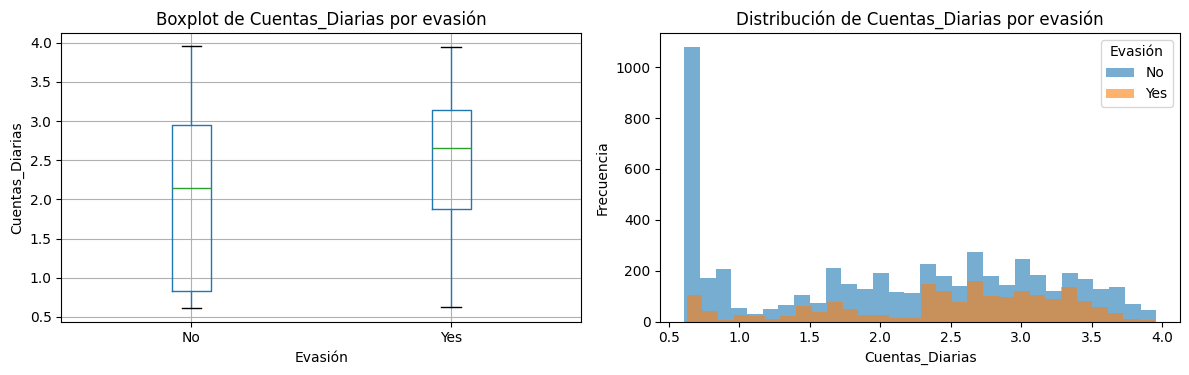

In [14]:
for col in ['Meses_Cliente', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df_es.boxplot(column=col, by='Evasion', ax=axes[0])
    axes[0].set_title(f'Boxplot de {col} por evasión')
    axes[0].set_xlabel('Evasión')
    axes[0].set_ylabel(col)

    for estado in ['No', 'Yes']:
        subset = df_es.loc[df_es['Evasion'] == estado, col]
        axes[1].hist(subset, bins=30, alpha=0.6, label=estado)
    axes[1].set_title(f'Distribución de {col} por evasión')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frecuencia')
    axes[1].legend(title='Evasión')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## 12. Informe final

### Introducción
Este análisis busca entender los factores asociados a la evasión de clientes de Telecom X.

### Limpieza y tratamiento
Se importó un JSON anidado, se aplanó con `pd.json_normalize()`, se corrigió el tipo de `Cargo_Total`, se trataron valores vacíos y se excluyeron registros sin valor de churn para el análisis.

### Análisis exploratorio
Se revisó la distribución general de churn, la evasión por categorías y las diferencias numéricas entre clientes que permanecen y clientes que cancelan.

### Conclusiones e insights
En general, la evasión suele ser mayor en contratos de corta permanencia, ciertos métodos de pago, clientes con menor antigüedad y segmentos sin servicios de soporte o seguridad.

### Recomendaciones
- impulsar contratos de mayor plazo,
- incentivar pagos automáticos,
- reforzar soporte y seguridad,
- activar campañas tempranas de retención.

In [15]:
tasa_evasion = df_es['Evasion'].eq('Yes').mean() * 100

contratos = pd.crosstab(df_es['Tipo_Contrato'], df_es['Evasion'], normalize='index').mul(100).round(2)
pagos = pd.crosstab(df_es['Metodo_Pago'], df_es['Evasion'], normalize='index').mul(100).round(2)
internet = pd.crosstab(df_es['Servicio_Internet'], df_es['Evasion'], normalize='index').mul(100).round(2)

meses_no = df_es.loc[df_es['Evasion'] == 'No', 'Meses_Cliente'].mean()
meses_si = df_es.loc[df_es['Evasion'] == 'Yes', 'Meses_Cliente'].mean()

resumen = f'''
# Resumen ejecutivo

**Base analizada:** {df_es.shape[0]:,} registros y {df_es.shape[1]} columnas.  
**Tasa general de evasión:** {tasa_evasion:.2f}%.

## Hallazgos clave
- Contrato **Month-to-month**: {contratos.loc['Month-to-month', 'Yes']:.2f}% de evasión.
- Contrato **One year**: {contratos.loc['One year', 'Yes']:.2f}% de evasión.
- Contrato **Two year**: {contratos.loc['Two year', 'Yes']:.2f}% de evasión.
- Método de pago con mayor evasión: **Electronic check** ({pagos.loc['Electronic check', 'Yes']:.2f}%).
- Internet **Fiber optic**: {internet.loc['Fiber optic', 'Yes']:.2f}% de evasión.
- Internet **DSL**: {internet.loc['DSL', 'Yes']:.2f}% de evasión.
- Antigüedad promedio de clientes que se quedan: {meses_no:.2f} meses.
- Antigüedad promedio de clientes que evaden: {meses_si:.2f} meses.

## Recomendaciones estratégicas
1. Migrar clientes mes a mes hacia contratos de mayor permanencia.
2. Incentivar medios de pago automáticos.
3. Implementar acciones de retención temprana.
4. Revisar la experiencia del segmento de fibra óptica y servicios asociados.
'''
display(Markdown(resumen))


# Resumen ejecutivo

**Base analizada:** 7,043 registros y 28 columnas.  
**Tasa general de evasión:** 26.54%.

## Hallazgos clave
- Contrato **Month-to-month**: 42.71% de evasión.
- Contrato **One year**: 11.27% de evasión.
- Contrato **Two year**: 2.83% de evasión.
- Método de pago con mayor evasión: **Electronic check** (45.29%).
- Internet **Fiber optic**: 41.89% de evasión.
- Internet **DSL**: 18.96% de evasión.
- Antigüedad promedio de clientes que se quedan: 37.57 meses.
- Antigüedad promedio de clientes que evaden: 17.98 meses.

## Recomendaciones estratégicas
1. Migrar clientes mes a mes hacia contratos de mayor permanencia.
2. Incentivar medios de pago automáticos.
3. Implementar acciones de retención temprana.
4. Revisar la experiencia del segmento de fibra óptica y servicios asociados.


## 13. Exportación opcional

In [16]:
df_es.to_csv('telecomx_clientes_limpio.csv', index=False)
print('Archivo exportado: telecomx_clientes_limpio.csv')

Archivo exportado: telecomx_clientes_limpio.csv
